📊 DATA ANALYZER PARA GOOGLE COLAB

📂 Faça upload do seu arquivo de dados:


Saving deepseek_csv_20260304_aae971.csv.txt to deepseek_csv_20260304_aae971.csv (2).txt

✅ Arquivo carregado: deepseek_csv_20260304_aae971.csv (2).txt
✅ Separador detectado: ','

📋 Dimensões: 16 linhas x 8 colunas

📊 Primeiras linhas:
         data           produto    categoria  quantidade  preco_unitario  \
0  2024-01-05     Notebook Dell  Informática           3          4500.0   
1  2024-01-05    Mouse Logitech  Periféricos          15            89.9   
2  2024-01-06  Teclado Mecânico  Periféricos           8           250.0   
3  2024-01-06        Monitor LG  Informática           5          1200.0   
4  2024-01-07   Notebook Lenovo  Informática           2          4200.0   

         vendedor    regiao             cliente  
0      João Silva       SUL         Empresa ABC  
1  Maria Oliveira   SUDESTE         João Santos  
2    Carlos Souza  NORDESTE           Loja Tech  
3       Ana Costa   SUDESTE  Escritório Central  
4      João Silva       SUL     Consultoria XYZ  

🔍 Estat

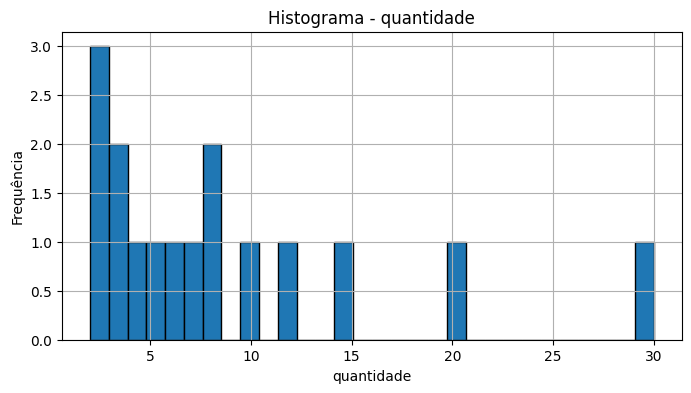

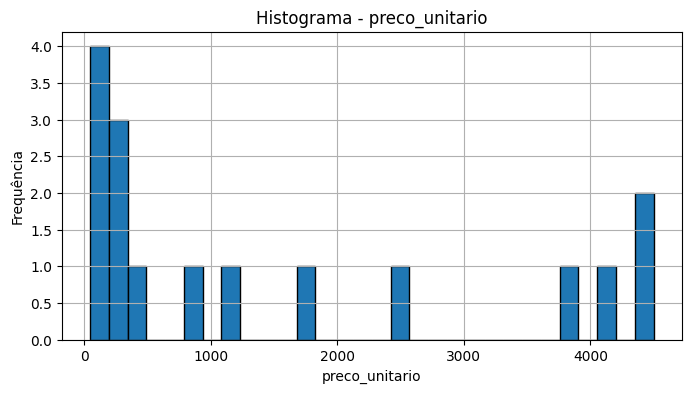

❌ Erro ao ler arquivo: could not convert string to float: '2024-01-05'

Tentando ler como texto simples...

📄 Conteúdo do arquivo:
data,produto,categoria,quantidade,preco_unitario,vendedor,regiao,cliente
2024-01-05,Notebook Dell,Informática,3,4500.00,João Silva,SUL,Empresa ABC
2024-01-05,Mouse Logitech,Periféricos,15,89.90,Maria Oliveira,SUDESTE,João Santos
2024-01-06,Teclado Mecânico,Periféricos,8,250.00,Carlos Souza,NORDESTE,Loja Tech
2024-01-06,Monitor LG,Informática,5,1200.00,Ana Costa,SUDESTE,Escritório Central
2024-01-07,Notebook Lenovo,Informática,2,4200.00,João Silva,SUL,Consultoria XYZ
2024-01-07,Impressora HP,Impr


<Figure size 1000x800 with 0 Axes>

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

def analisar_dados_colab():
    print("📊 DATA ANALYZER PARA GOOGLE COLAB")
    print("="*50)


    print("\n📂 Faça upload do seu arquivo de dados:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"\n✅ Arquivo carregado: {filename}")


        try:

            content = io.BytesIO(uploaded[filename])


            separadores = [',', ';', '\t', '|']
            df = None

            for sep in separadores:
                try:
                    content.seek(0)
                    df = pd.read_csv(content, encoding='utf-8', sep=sep)
                    if len(df.columns) > 1:
                        print(f"✅ Separador detectado: '{sep}'")
                        break
                except:
                    continue

            if df is None:

                content.seek(0)
                df = pd.read_csv(content, encoding='utf-8', sep=None, engine='python')

            print(f"\n📋 Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
            print(f"\n📊 Primeiras linhas:")
            print(df.head())

            print(f"\n🔍 Estatísticas descritivas:")
            print(df.describe())

            print(f"\n⚠️ Valores nulos:")
            print(df.isnull().sum())


            print("\n📈 Gerando gráficos...")


            numeric_cols = df.select_dtypes(include=[np.number]).columns[:3]
            for col in numeric_cols:
                plt.figure(figsize=(8, 4))
                df[col].hist(bins=30, edgecolor='black')
                plt.title(f'Histograma - {col}')
                plt.xlabel(col)
                plt.ylabel('Frequência')
                plt.show()


            if len(df.select_dtypes(include=[np.number]).columns) > 1:
                plt.figure(figsize=(10, 8))
                sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
                plt.title('Matriz de Correlação')
                plt.show()


            print("\n📋 INFORMAÇÕES DO DATASET:")
            print(f"Colunas: {list(df.columns)}")
            print(f"Tipos de dados:\n{df.dtypes}")

            return df

        except Exception as e:
            print(f"❌ Erro ao ler arquivo: {e}")
            print("\nTentando ler como texto simples...")


            content.seek(0)
            text_content = content.read().decode('utf-8')
            print("\n📄 Conteúdo do arquivo:")
            print(text_content[:500])

            return None


df = analisar_dados_colab()


if df is not None:
    df.to_csv('dados_processados.csv', index=False)
    files.download('dados_processados.csv')